# Convolution

In this notebook, we will show how a convolutional kernel passes across an image and the output is computed.

In [13]:
import matplotlib.pyplot as plt
import numpy as np

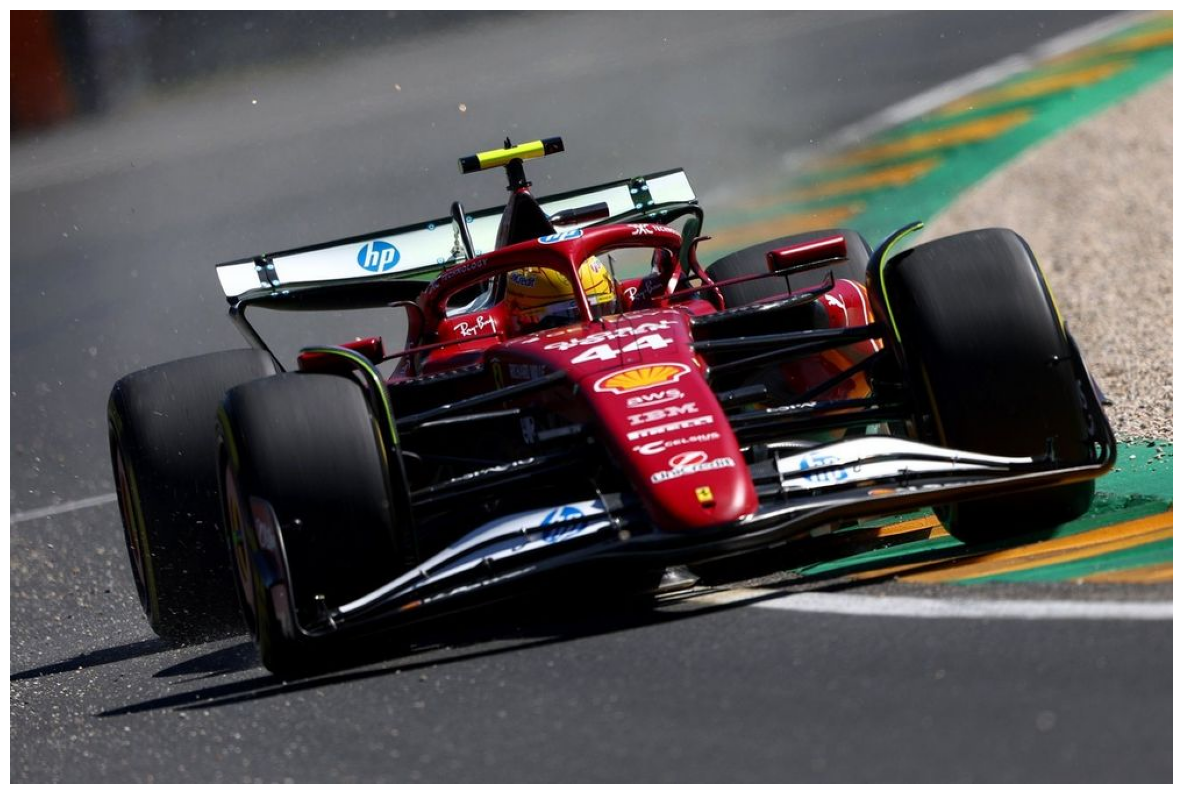

In [14]:
plt.figure(figsize=(15,15))
img = plt.imread(f"img_seg/ferrari.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

Here are a selection of different kernels that we can try out:

In [15]:
# Don't make any changes to the image
identity_kernel = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

# Blur the image a little
gaussian_kernel_3x3 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])

# Sharpen the edges
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Laplacian edge detection
laplacian_kernel_4 = np.array([
    [ 0,  1,  0],
    [ 1, -4,  1],
    [ 0,  1,  0]
])
# or
laplacian_kernel_8 = np.array([
    [ 1,  1,  1],
    [ 1, -8,  1],
    [ 1,  1,  1]
])

# Weird embossing effect
# You can also add 128 to the output BEFORE clipping to get an old school embossing effect
emboss_kernel = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
])


kernel = laplacian_kernel_8

# condition to normalize the kernel
if np.sum(kernel) != 0:
    kernel = kernel / np.sum(kernel)

In [16]:
img_h, img_w = img.shape[:2]
k_h, k_w = kernel.shape

We will apply some padding to the image so that the output is the same size as the input. The padding will be done by adding zeros around the image. The kernel will be applied to each pixel in the image, and the output will be computed by taking the element-wise product of the kernel and the image patch, and then summing the result.

In [17]:
pad_h = k_h // 2
pad_w = k_w // 2

padded_image = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)),
                              mode='constant', constant_values=0)
output_image = np.zeros_like(img, dtype=np.float64)
for y in range(img_h):
    for x in range(img_w):
        for c in range(img.shape[2]): # Iterate through channels
            patch = padded_image[y : y + k_h, x : x + k_w, c]
            # Element-wise multiplication and sum
            output_image[y, x, c] = np.sum(patch * kernel)

# final_image = output_image + img
final_image = np.clip(output_image, 0, 255).astype(np.uint8)

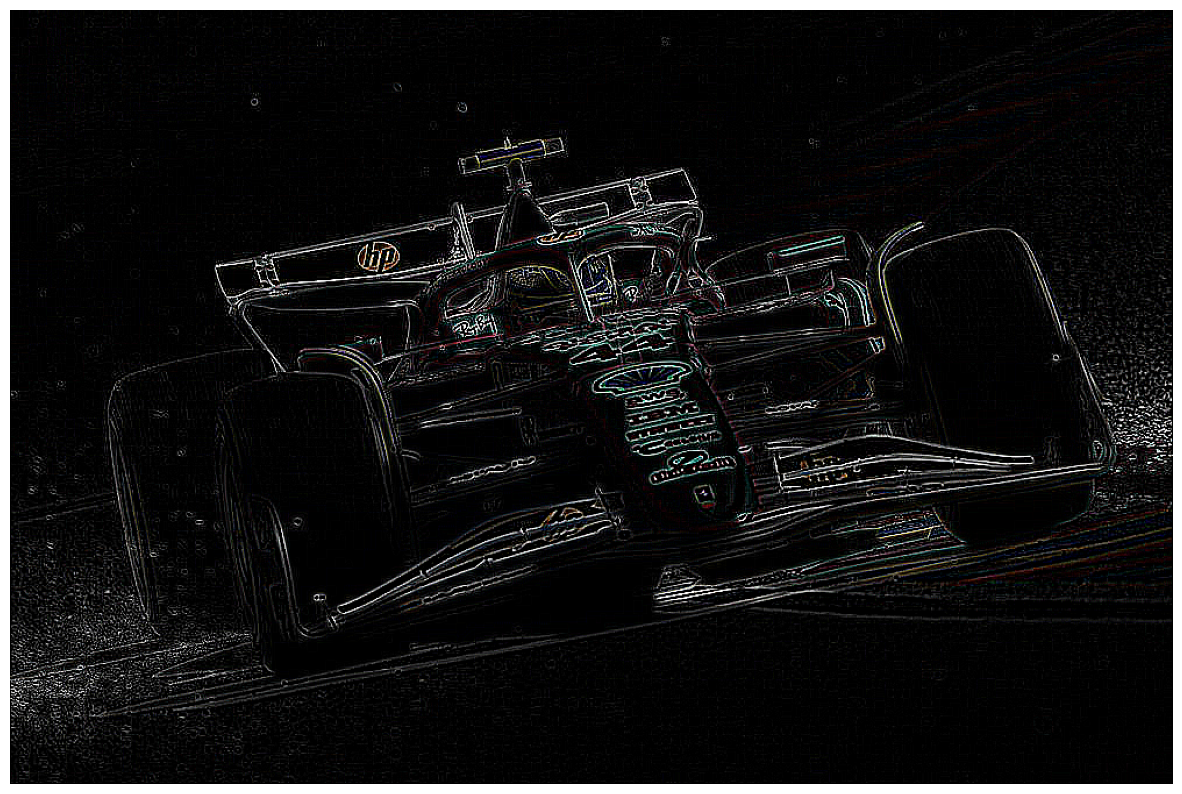

In [18]:
plt.figure(figsize=(15,15))
plt.imshow(final_image)
plt.axis("off")
plt.show()